## Analysis of the Corpus callosum --> the Body 


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

path = '/home/daniela/Documents/PROJECTS/Aging_DWI/CEDRE/CorrectedTracts2025'
CC_file= 'Body_CC_DTIvalues.csv'
df_CC_body= pd.read_csv(f"{path}/{CC_file}")
df_CC_body.head()


,list_sub,group,age,sex,JND_P,JND_T,IHD,FA_body,AD_body,MD_body,RD_body
0,sub-01,Y,25,F,9.56,4.21,0.534027,0.583124,0.001200,0.000678,0.000417
1,sub-02,Y,27,M,6.69,11.62,0.570600,0.613808,0.001163,0.000638,0.000375
2,sub-03,Y,28,F,12.92,3.79,-0.140120,0.627866,0.001173,0.000631,0.000361
3,sub-05,Y,21,F,1.95,1.28,0.488581,0.596784,0.001187,0.000665,0.000404
4,sub-06,Y,25,F,2.54,2.22,0.578001,0.637038,0.001197,0.000636,0.000356


/tmp/ipykernel_111118/2177422337.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(data=df_CC_body, x='group', y=DTImetric, ax=ax, hue='group', marker='o', linewidth=0.5,
/tmp/ipykernel_111118/2177422337.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(data=df_CC_body, x='group', y=DTImetric, ax=ax, hue='group', marker='o', linewidth=0.5,
/tmp/ipykernel_111118/2177422337.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(data=df_CC_body, x='group', y=DTImetric, ax=ax, hue='group', marker='o', linewidth=0.5,
/tmp/ipykernel_111118/2177422337.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will

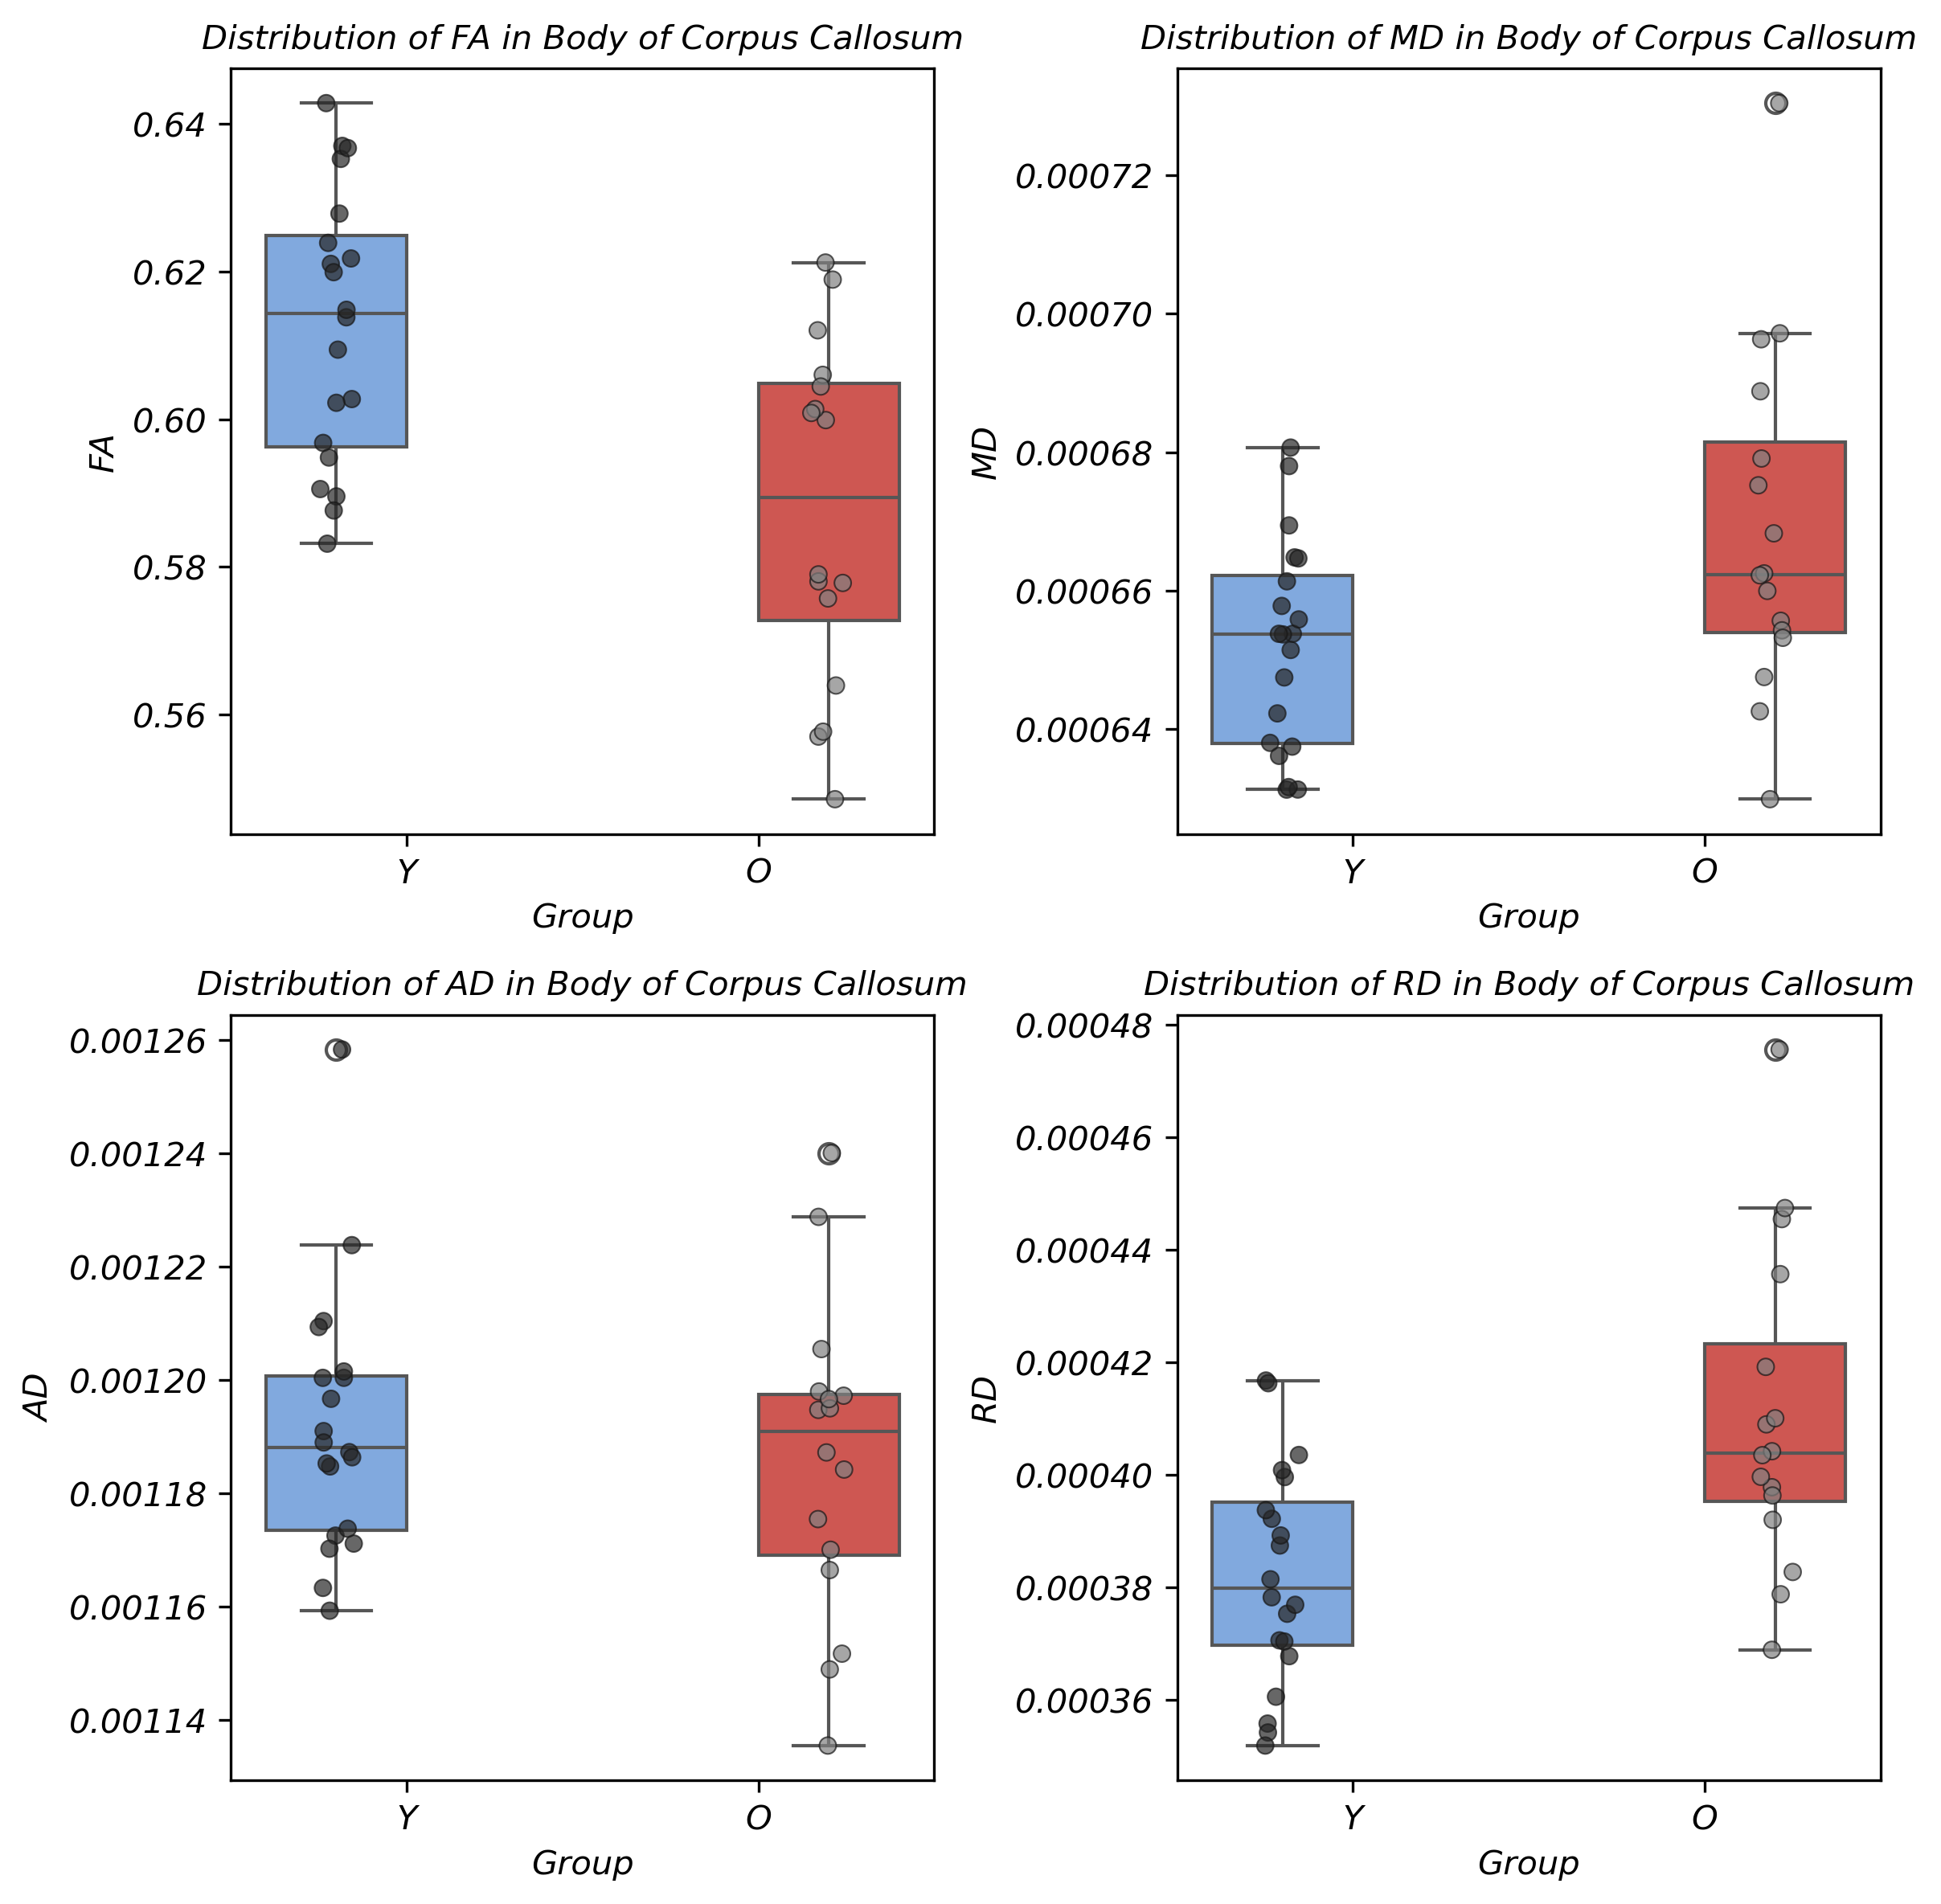

In [3]:

group_colors = {'Y': "#72a7ed", 'O': "#e2443e"}
metrics = ['FA', 'MD', 'AD', 'RD']
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    DTImetric = metric + '_body'
    sns.boxplot(data=df_CC_body, x='group', y=DTImetric, ax=ax, hue='group', dodge=True, palette=group_colors)
    sns.stripplot(data=df_CC_body, x='group', y=DTImetric, ax=ax, hue='group', marker='o', linewidth=0.5,
                  color='gray', alpha=0.7, dodge=True)
    # size of the tittles
    ax.set_title(f"Distribution of {metric} in Body of Corpus Callosum", fontsize=10)
    ax.set_xlabel('Group', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
# quality of the image - dpi=300
fig.set_dpi(300)

plt.tight_layout()
plt.show()

In [8]:
# statistical t test for metric in metrics:
from scipy.stats import ttest_ind
for metric in metrics:
    DTImetric = metric + '_body'
    group_Y = df_CC_body[df_CC_body['group'] == 'Y'][DTImetric]
    group_Y = group_Y.dropna()
    group_O = df_CC_body[df_CC_body['group'] == 'O'][DTImetric] 
    group_O = group_O.dropna()
    t_stat, p_value = ttest_ind(group_Y, group_O)
    print(f"{metric}: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}")
    # print descriptive statistics
    print(f"{metric} - Group Y: mean = {group_Y.mean():.3f}, std = {group_Y.std():.3f}, n = {len(group_Y)}")
    print(f"{metric} - Group O: mean = {group_O.mean():.3f}, std = {group_O.std():.3f}, n = {len(group_O)}")

FA: t-statistic = 3.583, p-value = 0.001
FA - Group Y: mean = 0.613, std = 0.018, n = 20
FA - Group O: mean = 0.588, std = 0.023, n = 16
MD: t-statistic = -2.514, p-value = 0.017
MD - Group Y: mean = 0.001, std = 0.000, n = 20
MD - Group O: mean = 0.001, std = 0.000, n = 16
AD: t-statistic = 0.684, p-value = 0.498
AD - Group Y: mean = 0.001, std = 0.000, n = 20
AD - Group O: mean = 0.001, std = 0.000, n = 16
RD: t-statistic = -3.548, p-value = 0.001
RD - Group Y: mean = 0.000, std = 0.000, n = 20
RD - Group O: mean = 0.000, std = 0.000, n = 16


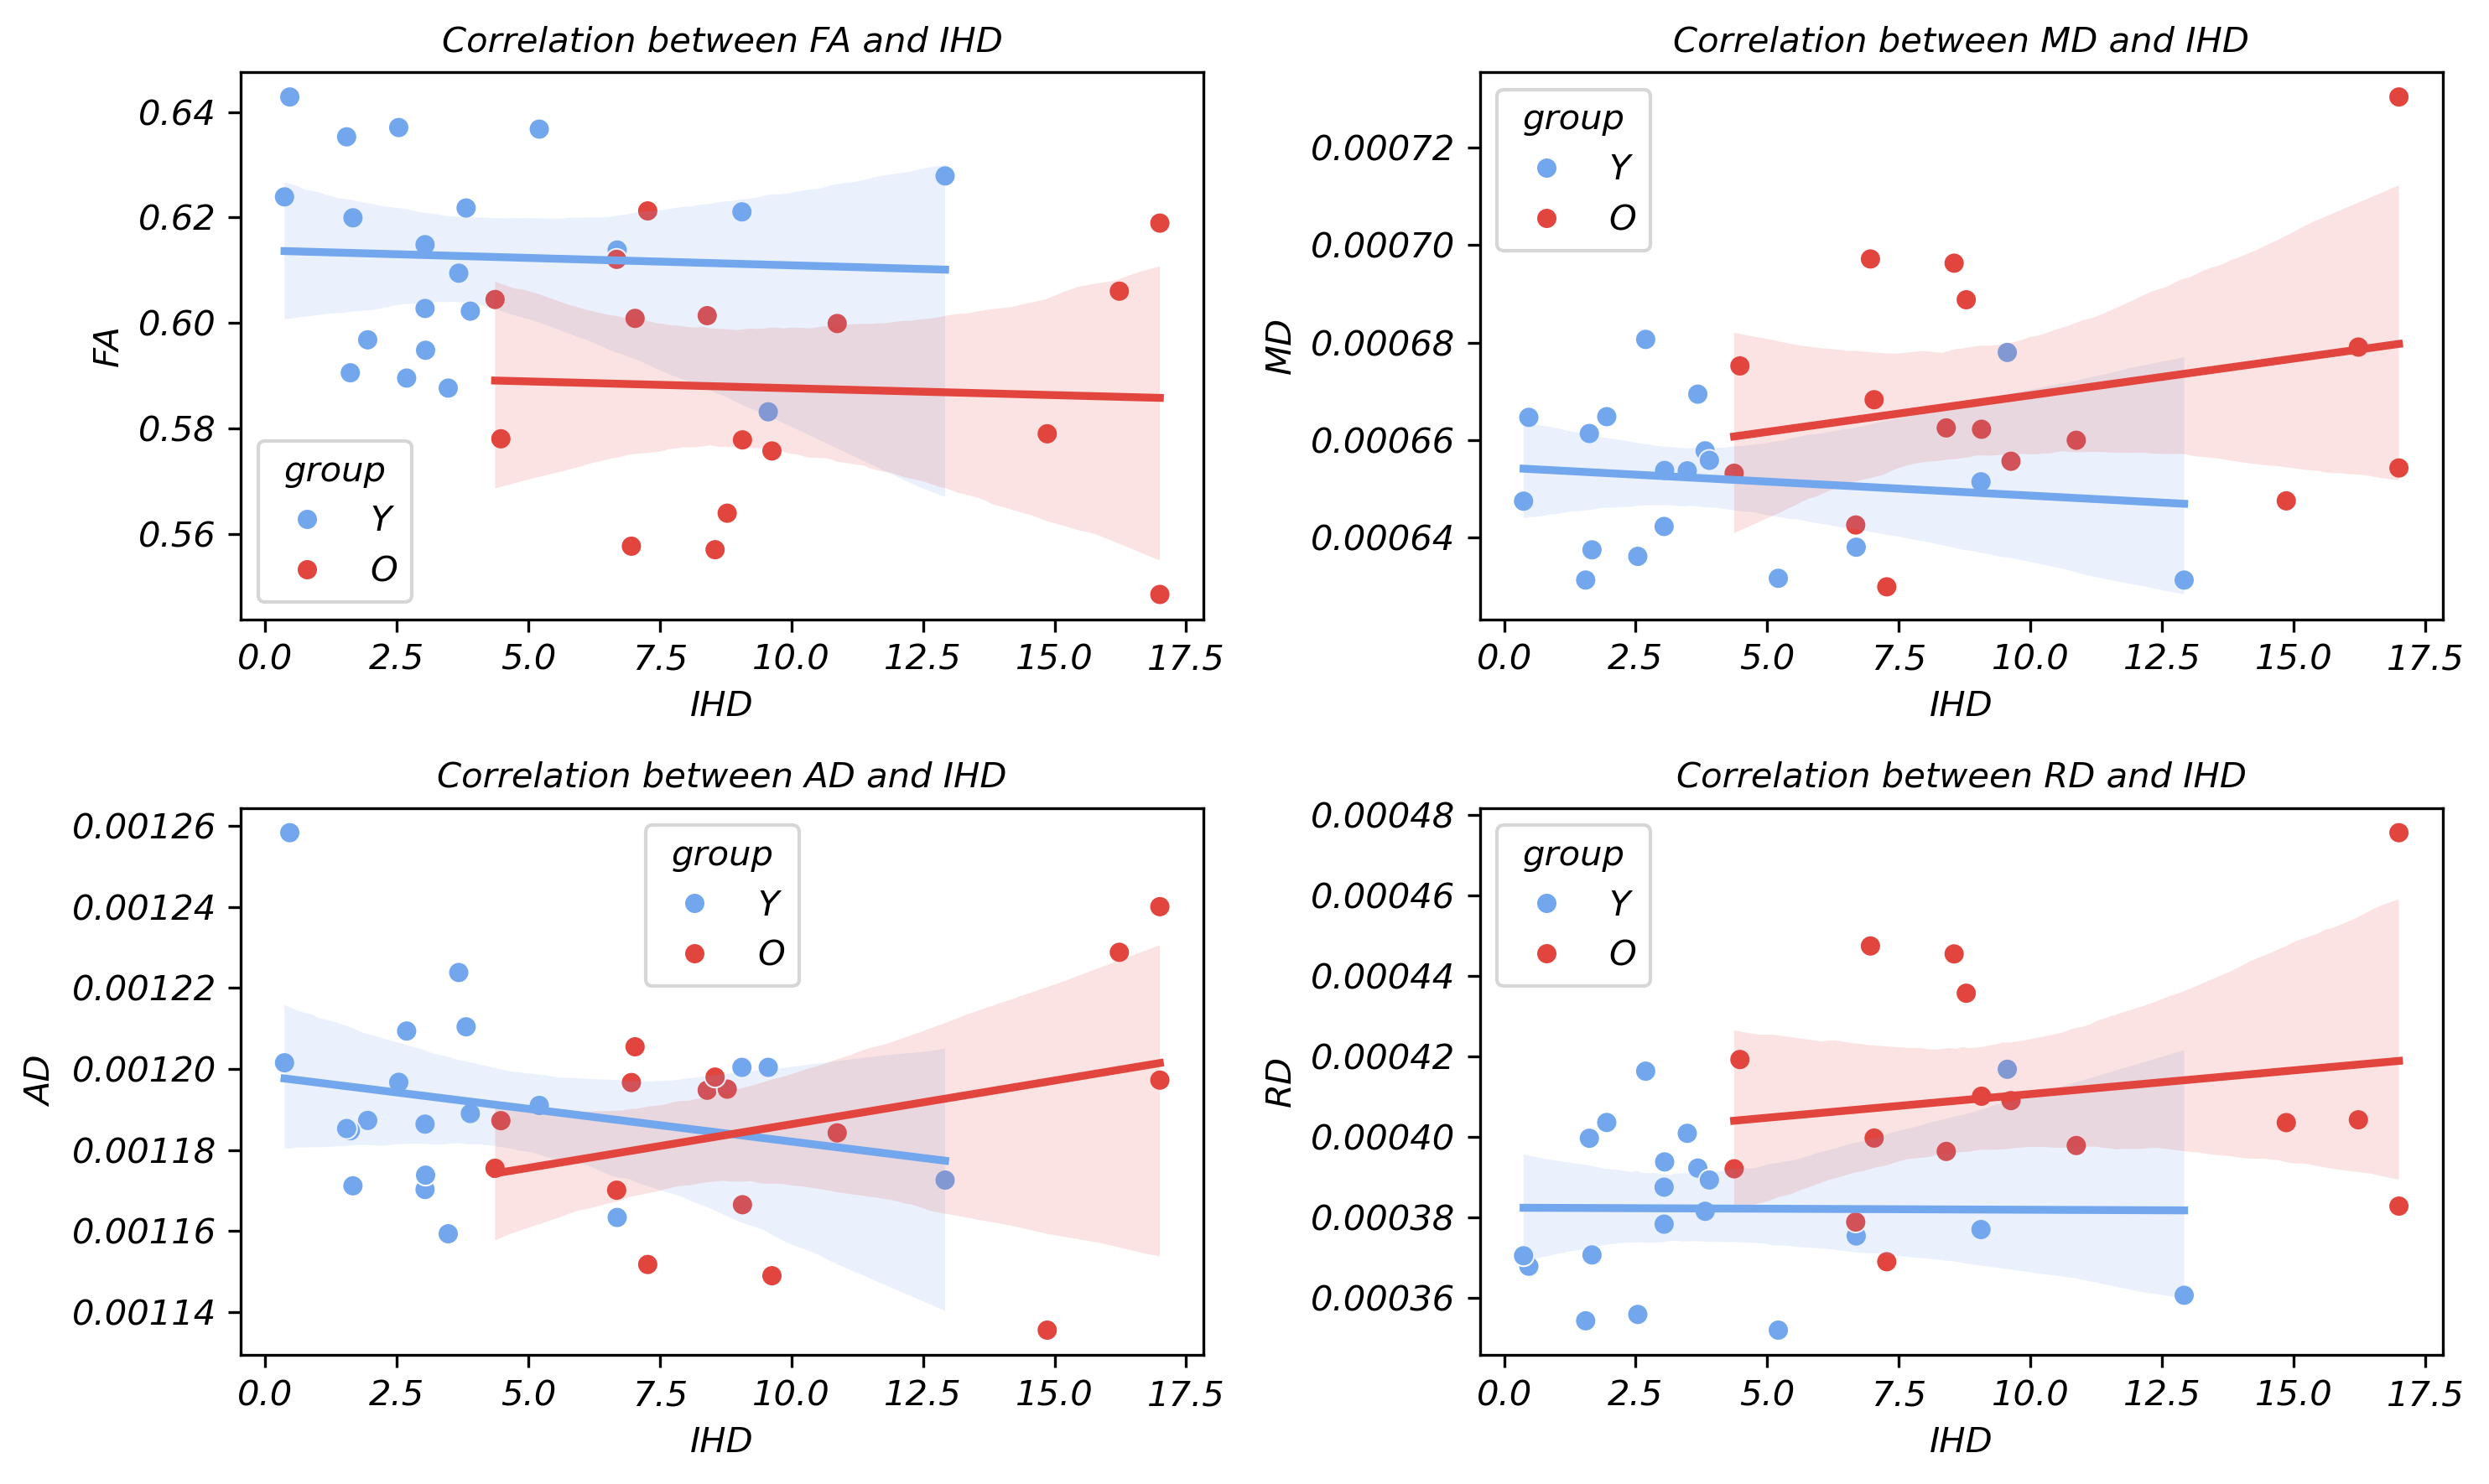

Metric: FA, Correlation: -0.36, p-value: 0.0313
Metric: MD, Correlation: 0.33, p-value: 0.0499
Metric: AD, Correlation: -0.01, p-value: 0.9497
Metric: RD, Correlation: 0.39, p-value: 0.0177
Group: Y, Metric: FA, Correlation: -0.05, p-value: 0.8371
Group: O, Metric: FA, Correlation: -0.05, p-value: 0.8629
Group: Y, Metric: MD, Correlation: -0.12, p-value: 0.6052
Group: O, Metric: MD, Correlation: 0.25, p-value: 0.3426
Group: Y, Metric: AD, Correlation: -0.23, p-value: 0.3329
Group: O, Metric: AD, Correlation: 0.33, p-value: 0.2147
Group: Y, Metric: RD, Correlation: -0.01, p-value: 0.9714
Group: O, Metric: RD, Correlation: 0.18, p-value: 0.5147


In [22]:
# correlation plots between the DTI measures in the Body_CC and the IHD, for each group
x_var = 'JND_P'
fig, axes = plt.subplots(2, 2, figsize=(10,6))
for ax, metric in zip(axes.flatten(), metrics):
    DTImetric = metric + '_body'
    sns.scatterplot(data=df_CC_body, x=x_var, y=DTImetric, hue='group', ax=ax, palette=group_colors)
    # add a regression line for each group
    sns.regplot(data=df_CC_body[df_CC_body['group'] == 'Y'], x=x_var, y=DTImetric, ax=ax, scatter=False, color=group_colors['Y'])
    sns.regplot(data=df_CC_body[df_CC_body['group'] == 'O'], x=x_var, y=DTImetric, ax=ax, scatter=False, color=group_colors['O'])
    ax.set_title(f"Correlation between {metric} and IHD", fontsize=10)
    ax.set_xlabel('IHD', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
fig.set_dpi(300)
plt.tight_layout()
plt.show()

# correlations between DTI metrics in the Body_CC and the JND across all population
for metric in metrics:
    DTImetric = metric + '_body'
    subset = df_CC_body.dropna(subset=[DTImetric, x_var])
    corr, p_value = pearsonr(subset[DTImetric], subset[x_var])
    print(f"Metric: {metric}, Correlation: {corr:.2f}, p-value: {p_value:.4f}")

# print correlation coefficients and p values for each group and each DTI metric    
from scipy.stats import pearsonr
for metric in metrics:
    DTImetric = metric + '_body'
    for group in ['Y', 'O']:
        subset = df_CC_body[df_CC_body['group'] == group]
        # eliminate rows with NaN values in the relevant columns
        subset = subset.dropna(subset=[DTImetric, x_var])
        corr, p_value = pearsonr(subset[DTImetric], subset[x_var])
        print(f"Group: {group}, Metric: {metric}, Correlation: {corr:.2f}, p-value: {p_value:.4f}")

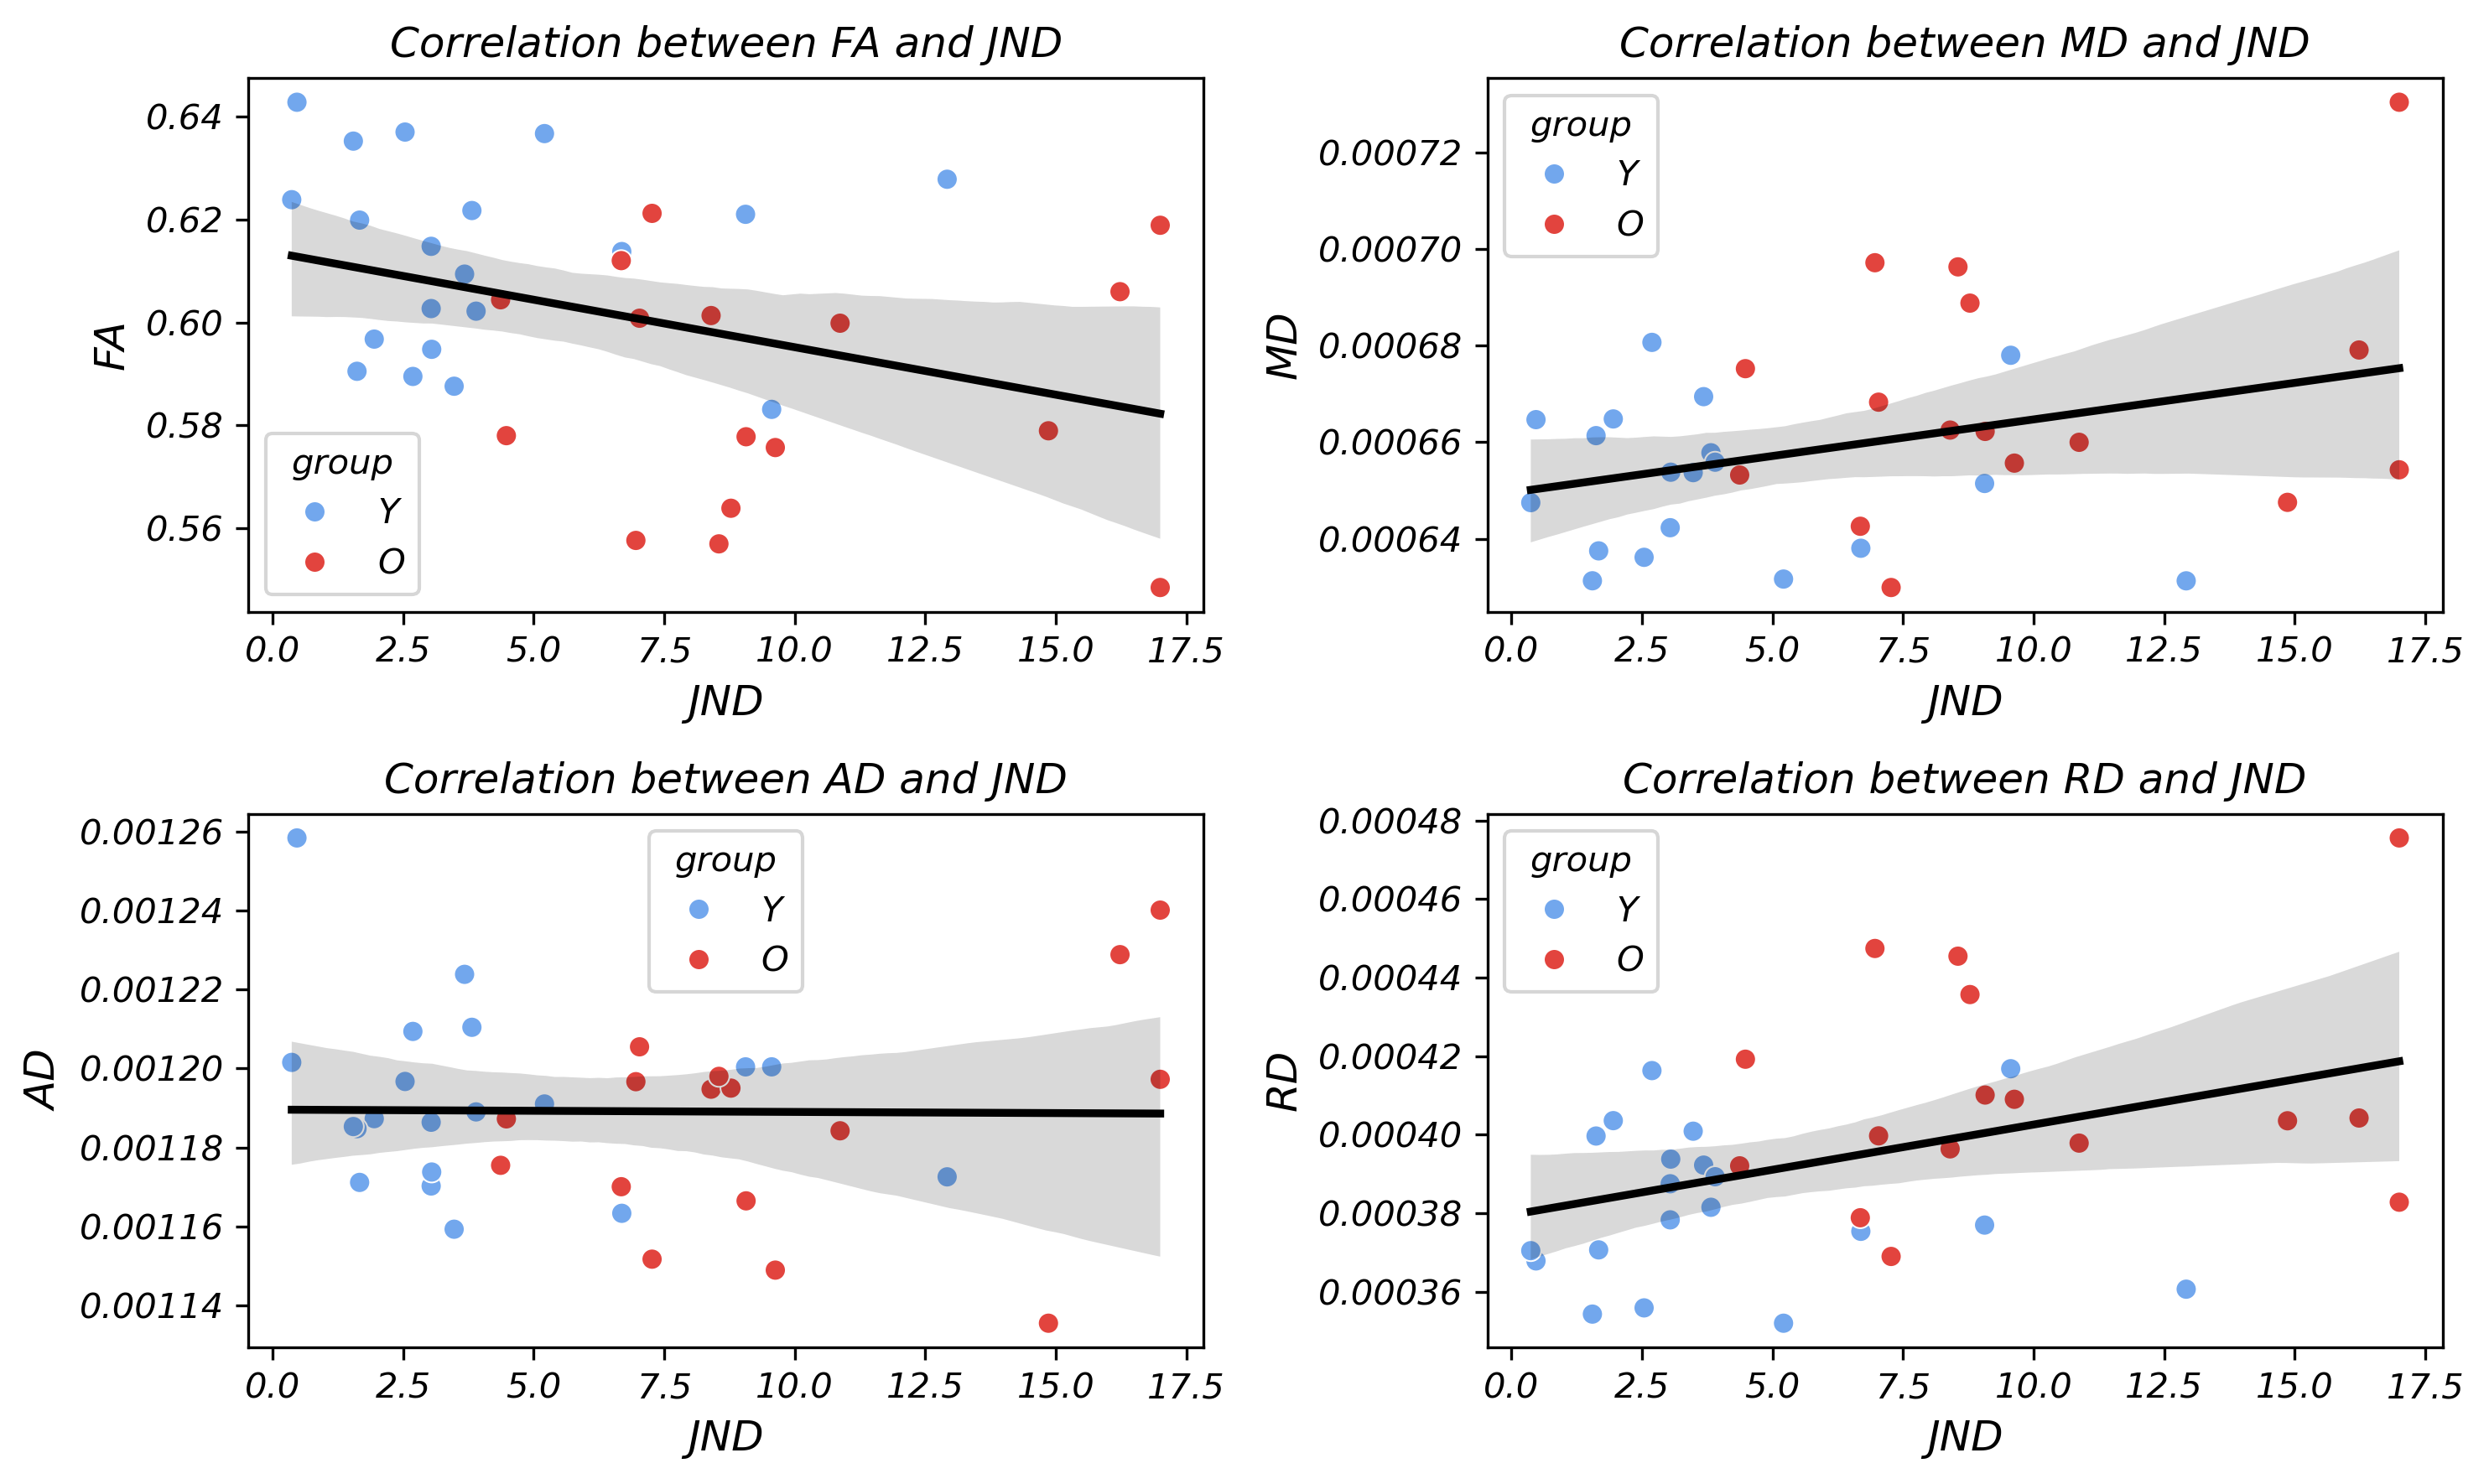

Metric: FA, Correlation: -0.36, p-value: 0.0313
Metric: MD, Correlation: 0.33, p-value: 0.0499
Metric: AD, Correlation: -0.01, p-value: 0.9497
Metric: RD, Correlation: 0.39, p-value: 0.0177


In [20]:
# correlations between DTI metrics in the Body_CC and the JND across all population, hue by color group
x_var = 'JND_P'
fig, axes = plt.subplots(2, 2, figsize=(10,6))
for ax, metric in zip(axes.flatten(), metrics): 
    DTImetric = metric + '_body'
    sns.scatterplot(data=df_CC_body, x=x_var, y=DTImetric, hue='group', ax=ax, palette=group_colors)
    # add a regression line  for all
    sns.regplot(data=df_CC_body, x=x_var, y=DTImetric, ax=ax, scatter=False, color='black')
    ax.set_title(f"Correlation between {metric} and JND", fontsize=12)
    ax.set_xlabel('JND', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
fig.set_dpi(300)
plt.tight_layout()
plt.show()

# correlations between DTI metrics in the Body_CC and the JND across all population
for metric in metrics:
    DTImetric = metric + '_body'
    subset = df_CC_body.dropna(subset=[DTImetric, x_var])
    corr, p_value = pearsonr(subset[DTImetric], subset[x_var])
    print(f"Metric: {metric}, Correlation: {corr:.2f}, p-value: {p_value:.4f}")